<h1 style="text-align:center;">Voting Access in Colorado - Geospatial Analysis of the 2024 Presidential Election</h1>

This analysis explores geographic access to voting locations across Colorado counties using spatial data. The goal is to quantify differences in access between regions and evaluate potential disparities in travel distance to voting sites.

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind
print(gpd.__version__)

1.1.3


# Import Cleaned Datasets

In [2]:
county_df = pd.read_csv("data/colorado_voter_data_by_county_2024.csv")
location_df = pd.read_csv("data/colorado_voter_data_by_location_2024.csv")

print("------------------------------Head of County Voting Dataset-----------------------------------")
print(county_df.head())
print("                                                                                              ")
print("-----------------------------Head of Voting Location Dataset----------------------------------")
print(location_df.head())

------------------------------Head of County Voting Dataset-----------------------------------
      county  num_sites  population  registered voters  democrat  republican  \
0      Adams         49      543760             320225    124056      103024   
1    Alamosa          4       16632              10321      3244        4057   
2   Arapahoe         49      666557             426537    190725      125311   
3  Archuleta          5       14137              11705      3904        5218   
4       Baca          3        3398               2582       275        1686   

   other  total votes  
0   6256       233336  
1    218         7519  
2   9415       325451  
3    233         9355  
4     43         2004  
                                                                                              
-----------------------------Head of Voting Location Dataset----------------------------------
              X             Y   county         site_type  \
0 -1.162854e+07  4.771434e+06 

# Import Colorado Map Data

In [3]:
counties = gpd.read_file("data/tl_2024_us_county/tl_2024_us_county.shp")

# Filter for Colorado, STATEFP = '08'
counties = counties[counties["STATEFP"] == "08"]

counties.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
22,08,109,00198170,08109,0500000US08109,Saguache,Saguache County,06,H1,G4020,None,None,None,A,8206547700,4454510,+38.0316514,-106.2346662,"POLYGON ((-107.00189 38.09291, -107.00188 38.0..."
105,08,115,00198173,08115,0500000US08115,Sedgwick,Sedgwick County,06,H1,G4020,None,None,None,A,1419419024,3530746,+40.8715679,-102.3553579,"POLYGON ((-102.65349 40.99999, -102.65348 41.0..."
122,08,017,00198124,08017,0500000US08017,Cheyenne,Cheyenne County,06,H1,G4020,None,None,None,A,4605713958,8166129,+38.8356456,-102.6017914,"POLYGON ((-102.54698 38.61343, -102.54734 38.6..."
161,08,027,00198129,08027,0500000US08027,Custer,Custer County,06,H1,G4020,None,None,None,A,1913031985,3364150,+38.1019955,-105.3735123,"POLYGON ((-105.7969 38.26505, -105.78341 38.26..."
198,08,067,00198148,08067,0500000US08067,La Plata,La Plata County,06,H1,G4020,None,20420,None,A,4376255274,25642579,+37.2873673,-107.8397178,"POLYGON ((-107.7124 36.99999, -107.71257 36.99..."


In [4]:
# Match coordinate systems
counties = counties.to_crs(epsg=4326)
counties["county"] = counties["NAME"].str.strip()

## Create GeoDataFrame

In [5]:
gdf = gpd.GeoDataFrame(
    location_df,
    geometry=gpd.points_from_xy(location_df["X"], location_df["Y"]),
    crs="EPSG:3857" # X and Y are not lat/lon values but are Web Mercator in meters (can tell from magnitude of values)
)

# Convert to lat/lon Coordinate Reference System (crs) for mapping
gdf = gdf.to_crs(epsg=4326)

gdf.head()

,X,Y,county,site_type,geocoded_address,population,registered voters,democrat,republican,other,total votes,geometry
0,-1.162854e+07,4.771434e+06,Elbert,dropbox,"440 Comanche St, Kiowa, Colorado, 80117",29337,23981,4768,15209,440,20417,POINT (-104.46091 39.34655)
1,-1.164366e+07,4.773512e+06,Elbert,dropbox,"151 S Banner St, Elizabeth, Colorado, 80107",29337,23981,4768,15209,440,20417,POINT (-104.5968 39.36098)
2,-1.164897e+07,4.788523e+06,Elbert,dropbox,"41082 Firehouse St, Parker, Colorado, 80138",29337,23981,4768,15209,440,20417,POINT (-104.64448 39.46517)
3,-1.171530e+07,4.642090e+06,Fremont,early vote,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)
4,-1.171530e+07,4.642090e+06,Fremont,polling location,"201 N 6th St, Canon City, Colorado, 81212",50071,32015,7526,17313,628,25467,POINT (-105.2403 38.44225)


## Assign Voting Locations to County

In [6]:
gdf = gpd.sjoin(gdf, counties, how="left", predicate="within")

## Examine Party Affliation and Voting Locations By County 

In [8]:
# merge counties with county_df
county_merged = counties.merge(county_df, on="county", how="left")

# Compute a normalized difference of vote
county_merged["dem_share"] = county_merged["democrat"]/county_merged["total votes"]
county_merged["rep_share"] = county_merged["republican"]/county_merged["total votes"]

# Coded for heatmap so (+) = democratic leaning and (-) = republican leaning
county_merged["partisan_lean"] = county_merged["dem_share"] - county_merged["rep_share"]

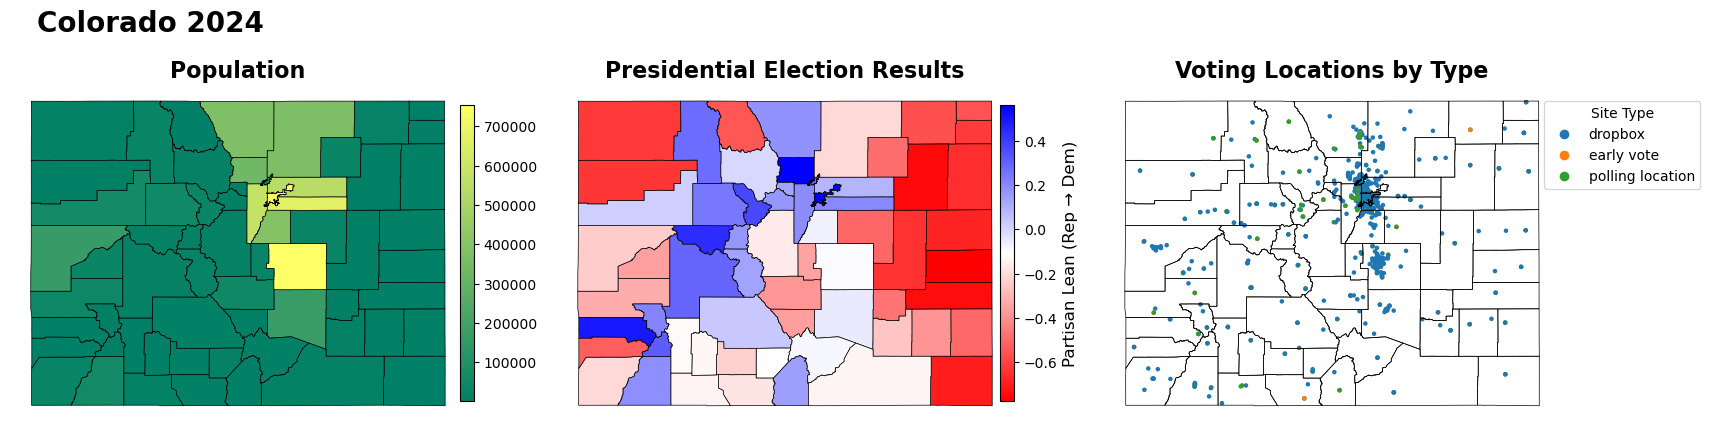

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20,8))

#------------------------Population Plot--------------------------
cax_pop = fig.add_axes([0.35, 0.31, 0.007, 0.37])

county_merged.plot(
    column="population",
    cmap="summer",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=axes[0],
    cax=cax_pop
)

axes[0].set_title(
    "Population",
    fontweight='bold',
    fontsize=16
)
axes[0].axis("off")
# Colorbar label
#cax_pop.set_ylabel("Population (Low → High)", fontsize=12)


#----------------Voting Results by County Plot---------------------

cax_party = fig.add_axes([0.62, 0.31, 0.007, 0.37])

county_merged.plot(
    column="partisan_lean",
    cmap="bwr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    cax=cax_party,
    ax=axes[1]
)

axes[1].set_title(
    "Presidential Election Results",
    fontweight='bold',
    fontsize=16
)
axes[1].axis("off")
# Colorbar label
cax_party.set_ylabel("Partisan Lean (Rep → Dem)", fontsize=12)

#------------------- Voting Locations Plot-----------------------

# Set color of site types to match legend
color_map = {
    "dropbox": "#1f77b4",          # blue
    "early vote": "#ff7f0e",       # orange
    "polling location": "#2ca02c"  # green
}

gdf["color"] = gdf["site_type"].map(color_map)

gdf.plot(
    color=gdf["color"],
    markersize=5,
    ax=axes[2]
)

# Add county boundries
counties.boundary.plot(ax=axes[2], linewidth=0.5, color="black")

# Create color mapping
site_order = ["dropbox", "early vote", "polling location"]
colors = plt.cm.tab10(range(len(site_order)))

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label=site,
           markerfacecolor=color_map[site],
           markersize=8)
    for site in site_order
]

axes[2].legend(
    handles=legend_elements,
    title="Site Type",
    loc="upper left",
    bbox_to_anchor=(0.95, 0.975)
)

axes[1].set_xlim(axes[0].get_xlim())
axes[1].set_ylim(axes[0].get_ylim())

axes[2].set_xlim(axes[0].get_xlim())
axes[2].set_ylim(axes[0].get_ylim())

axes[2].set_title(
    "Voting Locations by Type", 
    fontweight='bold',
    fontsize=16
)

axes[2].axis("off")

fig.suptitle("Colorado 2024", fontweight='bold', fontsize=20, y=0.8, x=0.195)
# save option
#plt.savefig('results/colorado_county_maps_election_results_voting_locations_population_2024.png')
plt.show()

# Community Type

In [11]:
# counties that generated 50 million or more in revenue - USDA 2022 Censuse of Agriculture (Kelly & Legislative Council Staff, 2023)
agg_counties = ["Weld", "Yuma", "Logan", "Morgan", "Kit Carson", "Prowers", "Washington", "Phillips", "Larimer", "Adams", "Sedgwick",
               "Mesa", "Delta", "Montrose", "Rio Grande", "Alamosa", "Pueblo", "Crowley", "Lincoln", "Cheyenne", "Kiowa", "Otero",
               "Bent", "Baca"]
agg_county_df = county_merged[county_merged['county'].isin(agg_counties)]
agg_county_df.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,num_sites,population,registered voters,democrat,republican,other,total votes,dem_share,rep_share,partisan_lean
1,08,115,00198173,08115,0500000US08115,Sedgwick,Sedgwick County,06,H1,G4020,...,3,2278,1693,283,1048,27,1358,0.208395,0.771723,-0.563328
2,08,017,00198124,08017,0500000US08017,Cheyenne,Cheyenne County,06,H1,G4020,...,4,1737,1253,108,930,17,1055,0.102370,0.881517,-0.779147
8,08,003,00198117,08003,0500000US08003,Alamosa,Alamosa County,06,H1,G4020,...,4,16632,10321,3244,4057,218,7519,0.431440,0.539566,-0.108126
9,08,099,00198165,08099,0500000US08099,Prowers,Prowers County,06,H1,G4020,...,3,11944,7157,1227,3833,84,5144,0.238530,0.745140,-0.506610
13,08,101,00198166,08101,0500000US08101,Pueblo,Pueblo County,06,H1,G4020,...,22,169916,115840,39328,43688,2091,85107,0.462101,0.513330,-0.051230


In [12]:
# Check all counties were selected
print(len(agg_county_df['county']))
print(len(agg_counties))

24
24


In [13]:
# Counties with populare ski resorts
ski_counties = ["Summit", "Eagle", "Pitkin", "Routt", "San Miguel", "Gunnison", "Grand"]
ski_county_df = county_merged[county_merged['county'].isin(ski_counties)]
ski_county_df.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,num_sites,population,registered voters,democrat,republican,other,total votes,dem_share,rep_share,partisan_lean
6,08,097,00198164,08097,0500000US08097,Pitkin,Pitkin County,06,H1,G4020,...,5,16593,14211,7932,2992,243,11167,0.710307,0.267932,0.442375
12,08,117,00198174,08117,0500000US08117,Summit,Summit County,06,H1,G4020,...,10,30889,21881,11762,5244,536,17542,0.670505,0.298940,0.371565
17,08,037,00198134,08037,0500000US08037,Eagle,Eagle County,06,H1,G4020,...,18,54196,34521,16943,10148,707,27798,0.609504,0.365062,0.244442
18,08,113,00198172,08113,0500000US08113,San Miguel,San Miguel County,06,H1,G4020,...,6,7802,6140,3529,1154,121,4804,0.734596,0.240216,0.494380
38,08,107,00198169,08107,0500000US08107,Routt,Routt County,06,H1,G4020,...,8,25241,20009,10208,5676,451,16335,0.624916,0.347475,0.277441


In [14]:
# Check all counties were selected
print(len(ski_county_df))
print(len(ski_counties))

7
7


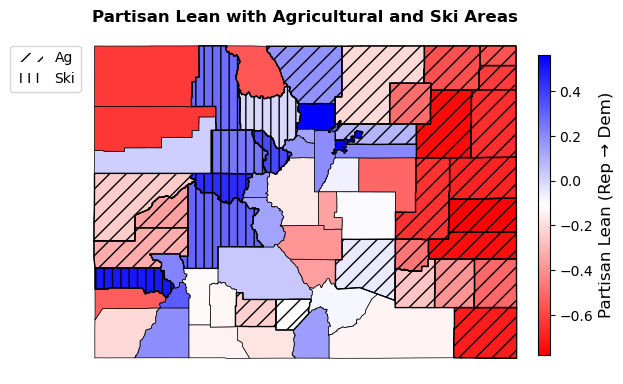

In [15]:
fig, ax = plt.subplots(1, figsize=(6,6))

# Plot Layer 1: Partisan Lean

cax_party = fig.add_axes([0.9, 0.24, 0.02, 0.5])

county_merged.plot(
    column="partisan_lean",
    cmap="bwr_r",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    cax=cax_party,
    ax=ax
)

# Layer 2: Agricultural Communities
agg_county_df.plot(
    column="county",
    facecolor='none',
    edgecolor='black',
    hatch='//',
    linewidth=1,
    ax=ax
)

# Layer 3: Ski Communities
ski_county_df.plot(
    column="county",
    facecolor='none',
    edgecolor='black',
    hatch='||',
    linewidth=1,
    ax=ax
)

# Colorbar label
cax_party.set_ylabel("Partisan Lean (Rep → Dem)", fontsize=12)

hatch1 = mpatches.Patch(facecolor='white', hatch='//', label='Ag')
hatch2 = mpatches.Patch(facecolor='white', hatch='||', label='Ski')
ax.legend(handles=[hatch1, hatch2], bbox_to_anchor=(-0.15, 0.975), loc="upper left")

ax.set_title("Partisan Lean with Agricultural and Ski Areas", fontweight='bold')
ax.axis('off') 

# optional save
#plt.savefig('results/colorado_county_maps_election_results_community_type_2024.png')
plt.show()

# Population-Weighted Centroid Analysis

In [27]:
# Distance in lat/lon, use 26913 the NAD83/UTM zone 13N projected crs often used for central western U.S. including Colorado
gdf = gdf.to_crs(epsg=26913)
counties = counties.to_crs(epsg=26913)

# Compute county centroids
counties["centroid"] = counties.geometry.centroid

# Create a GeoDataFrame for centroids
centroids = gpd.GeoDataFrame(
    counties[["county"]],
    geometry=counties["centroid"],
    crs=counties.crs
)



In [28]:
centroids.head()

,county,geometry
22,Saguache,POINT (387657.473 4215549.199)
105,Sedgwick,POINT (723149.814 4528363.372)
122,Cheyenne,POINT (708048.28 4300438.809)
161,Custer,POINT (467789.909 4217938.788)
198,La Plata,POINT (247910.449 4130429.407)


In [29]:
# Distance to nearest voting site
from shapely.ops import nearest_points

def nearest_distance(point, locations):
    nearest_geom = locations.geometry.union_all()
    nearest_point = nearest_points(point, nearest_geom)[1]
    return point.distance(nearest_point)

centroids["distance_to_site_m"] = centroids.geometry.apply(
    lambda x: nearest_distance(x, gdf)
)

# Convert to miles, epsg:"26913" is in meters
centroids["distance_to_site_miles"] = centroids["distance_to_site_m"] / 1609.34

# Merge with county data
county_merged = county_merged.merge(
    centroids[["county", "distance_to_site_miles"]],
    on="county",
    how="left"
)


In [31]:
county_merged.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,...,registered voters,democrat,republican,other,total votes,dem_share,rep_share,partisan_lean,distance_to_site_miles_x,distance_to_site_miles_y
0,08,109,00198170,08109,0500000US08109,Saguache,Saguache County,06,H1,G4020,...,4622,1704,1577,119,3400,0.501176,0.463824,0.037353,7.855692,7.855692
1,08,115,00198173,08115,0500000US08115,Sedgwick,Sedgwick County,06,H1,G4020,...,1693,283,1048,27,1358,0.208395,0.771723,-0.563328,9.025723,9.025723
2,08,017,00198124,08017,0500000US08017,Cheyenne,Cheyenne County,06,H1,G4020,...,1253,108,930,17,1055,0.102370,0.881517,-0.779147,11.073629,11.073629
3,08,027,00198129,08027,0500000US08027,Custer,Custer County,06,H1,G4020,...,4722,1188,2583,96,3867,0.307215,0.667960,-0.360745,5.536297,5.536297
4,08,067,00198148,08067,0500000US08067,La Plata,La Plata County,06,H1,G4020,...,44231,20677,14024,980,35681,0.579496,0.393038,0.186458,1.731043,1.731043


In [35]:
# Compare distance results between ski and ag communities
agg_county_df = county_merged[county_merged['county'].isin(agg_counties)]
ski_county_df = county_merged[county_merged['county'].isin(ski_counties)]

print("Agricultural counties avg distance:",
      agg_county_df["distance_to_site_miles_x"].mean())

print("Ski counties avg distance:",
      ski_county_df["distance_to_site_miles_x"].mean())

Agricultural counties avg distance: 8.157228795319307
Ski counties avg distance: 5.688563223886317


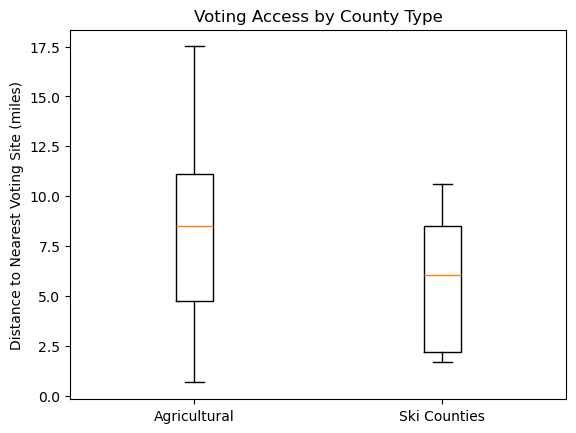

In [36]:
data = [
    agg_county_df["distance_to_site_miles_x"],
    ski_county_df["distance_to_site_miles_x"]
]

plt.figure()
plt.boxplot(data, tick_labels=["Agricultural", "Ski Counties"])

plt.ylabel("Distance to Nearest Voting Site (miles)")
plt.title("Voting Access by County Type")

plt.show()

## Welch’s t-test to compare means
- Appropriate to compare the means of two independent samples when sample sizes and variances are unequal.

In [37]:
t_stat, p_value = ttest_ind(
    agg_county_df["distance_to_site_miles_x"],
    ski_county_df["distance_to_site_miles_x"],
    equal_var=False  
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.4769536368069482
p-value: 0.16781966650302269


# Analysis Based on Partisan Lean

In [39]:
rep_lean_df = county_merged[county_merged['partisan_lean'] < -0.2]
dem_lean_df = county_merged[county_merged['partisan_lean'] > 0.2]


In [40]:
print("Republican leaning counties avg distance:",
      rep_lean_df["distance_to_site_miles_x"].mean())

print("Democratic leaning avg distance:",
     dem_lean_df["distance_to_site_miles_x"].mean())

Republican leaning counties avg distance: 9.581833785164587
Democratic leaning avg distance: 5.07047564150482


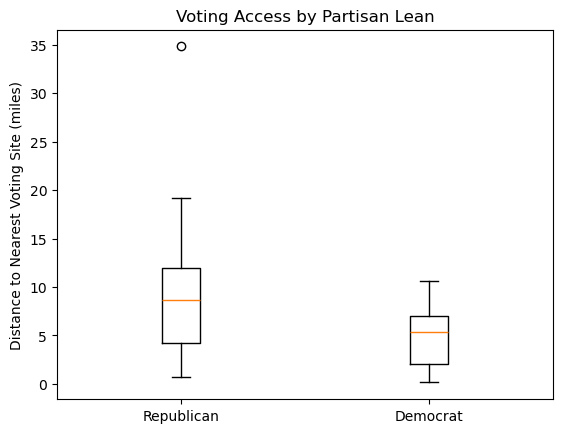

In [41]:
data = [
    rep_lean_df["distance_to_site_miles_x"],
    dem_lean_df["distance_to_site_miles_x"]
]

plt.figure()
plt.boxplot(data, tick_labels=["Republican", "Democrat"])

plt.ylabel("Distance to Nearest Voting Site (miles)")
plt.title("Voting Access by Partisan Lean")

plt.show()

In [42]:
t_stat, p_value = ttest_ind(
    rep_lean_df["distance_to_site_miles_x"],
    dem_lean_df["distance_to_site_miles_x"],
    equal_var=False  
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.750443500628476
p-value: 0.009039525545530214
